# Random Forest

In [2]:
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np

In [3]:
ds = load_dataset("google/code_x_glue_cc_clone_detection_big_clone_bench")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/142M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

data/train-00003-of-00006.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

data/train-00004-of-00006.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

data/train-00005-of-00006.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

data/validation-00000-of-00003.parquet:   0%|          | 0.00/79.3M [00:00<?, ?B/s]

data/validation-00001-of-00003.parquet:   0%|          | 0.00/79.4M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/79.4M [00:00<?, ?B/s]

data/test-00000-of-00003.parquet:   0%|          | 0.00/73.3M [00:00<?, ?B/s]

data/test-00001-of-00003.parquet:   0%|          | 0.00/73.5M [00:00<?, ?B/s]

data/test-00002-of-00003.parquet:   0%|          | 0.00/73.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/901028 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/415416 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/415416 [00:00<?, ? examples/s]

## Vectorisation du dataset

In [4]:
df_train = ds['train'].to_pandas()
df_test = ds['test'].to_pandas()

In [5]:
X_train_text = df_train['func1'] + " [SEP] " + df_train['func2']
X_test_text = df_test['func1'] + " [SEP] " + df_test['func2']

y_train = df_train['label']
y_test = df_test['label']

In [6]:
del df_train, df_test

In [7]:
tfidf = TfidfVectorizer(max_features=100000, stop_words='english')

In [8]:
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

## Entrainement

In [65]:
rf_model = RandomForestClassifier(
    n_estimators=200,        # Nombre d'arbres (augmenté car vous avez de la RAM)
    criterion='gini',
    max_depth=50,          
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',     # Standard pour la classification
    class_weight='balanced', # CRUCIAL pour vos données déséquilibrées
    n_jobs=-1,               # Utilisation de tous les processeurs
    random_state=42,
    verbose=1                # Pour suivre l'avancement
)

In [67]:
rf_model.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed: 29.2min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 34.8min finished


,n_estimators,200
,criterion,'gini'
,max_depth,50
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluation

In [68]:
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    2.2s
[Parallel(n_jobs=20)]: Done 200 out of 200 | elapsed:    2.6s finished


## Interpretation des résultats

In [69]:
train_acc = rf_model.score(X_train, y_train)

print(f"Accuracy Train : {train_acc:.4f}")
print(f"Accuracy Test  : {acc:.4f}")

# Calcul de l'écart (Gap)
gap = train_acc - acc
print(f"Ecart : {gap:.4f}")

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.6s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    5.3s


Accuracy Train : 0.9919
Accuracy Test  : 0.9660
Ecart : 0.0259


[Parallel(n_jobs=20)]: Done 200 out of 200 | elapsed:    6.4s finished


On constate une accuracy de 99% sur les données d'entrainment et 96% sur les données de test. Cela montre que notre modéle généralise bien.

In [70]:
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))


Rapport de classification :
              precision    recall  f1-score   support

       False       0.98      0.98      0.98    358596
        True       0.89      0.86      0.87     56820

    accuracy                           0.97    415416
   macro avg       0.93      0.92      0.93    415416
weighted avg       0.97      0.97      0.97    415416



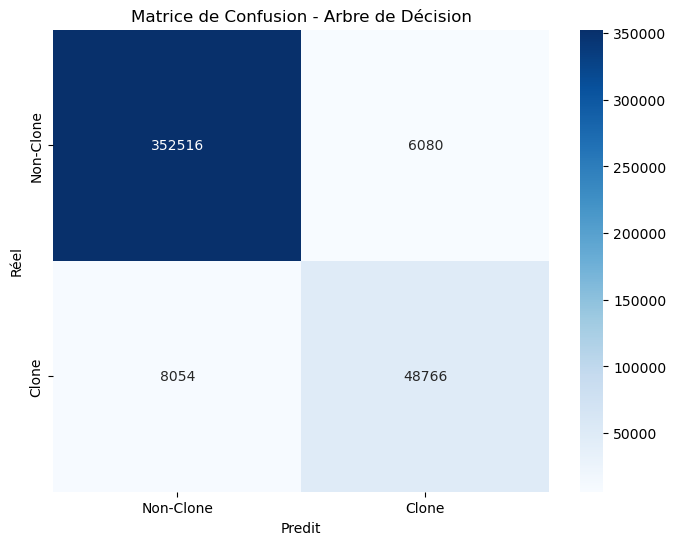

In [71]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
# Affichage
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Clone', 'Clone'], 
            yticklabels=['Non-Clone', 'Clone'])
plt.xlabel('Predit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion - Arbre de Décision')
plt.show()